<a href="https://colab.research.google.com/github/ritterb64/neocredit_limpieza_datos/blob/main/neocredit_limpiza_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##LIMPIEZA DE DATOS NeoCredit SA
##Profesora: Adriana Collaguazo
##Integrantes:

*   Ritter Briones
*   Mariana Mora
*   Anthony Polo






**Paso 1: Preparación del entorno de trabajo**

In [ ]:
#instalacion de librearia pandera
!pip install pandera ydata-profiling missingno -q

#importar librerias
import pandas as pd
import numpy as np
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import(
    MinMaxScaler
    ,RobustScaler
    ,MaxAbsScaler
    ,StandardScaler
    ,PowerTransformer
    ,Normalizer)
import pandera.pandas as pa
from pandera import  Column,Check,DataFrameSchema

In [ ]:
#lectura de dataset
df=pd.read_csv("/content/solicitudes_credito_neocredit.csv")

**Paso 2: Exploración inicial y perfilado de datos**

In [6]:
#inspeccion de tipo de datos
df.info()
#el data frame cuenta con con 669  registros
#se observa que fecha_solicitud y canal_solicitud son las columna con mayor cantidad de datos faltantes
# existen columnas object que deberian ser numericos como por ejemplo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_solicitud               669 non-null    object 
 1   id_cliente                 663 non-null    object 
 2   nombre_cliente             663 non-null    object 
 3   edad                       663 non-null    float64
 4   genero                     578 non-null    object 
 5   ciudad                     614 non-null    object 
 6   ingreso_mensual            642 non-null    object 
 7   tipo_empleo                607 non-null    object 
 8   antiguedad_laboral_meses   663 non-null    float64
 9   monto_solicitado           663 non-null    float64
 10  plazo_meses                663 non-null    float64
 11  score_buro_externo         635 non-null    float64
 12  deuda_actual               663 non-null    float64
 13  num_tarjetas_activas       663 non-null    float64

In [7]:
#estadistica descriptiva
df.describe(include="all")
#se observan valores atipicos en edad donde el minimo valor es -5 y maximo 210
#se observan valores atipicos en antiguedad_laboral_meses donde el minimo valor es -12

,id_solicitud,id_cliente,nombre_cliente,edad,genero,ciudad,ingreso_mensual,tipo_empleo,antiguedad_laboral_meses,monto_solicitado,...,score_buro_externo,deuda_actual,num_tarjetas_activas,historial_pagos_atrasados,fecha_solicitud,canal_solicitud,dispositivo,ip_pais,resultado_solicitud,fraude_flag
count,669,663,663,663.000000,578,614,642,607,663.000000,663.000000,...,635.000000,663.000000,663.000000,663.000000,570,572,563,663,663,663.000000
unique,656,529,560,NaN,7,12,610,8,NaN,NaN,...,NaN,NaN,NaN,NaN,505,7,6,7,5,NaN
top,SOL-10630,CLI-1215,Ambrosio Barrera,NaN,F,Cuenca,No disponible,independiente,NaN,NaN,...,NaN,NaN,NaN,NaN,2025-12-16,Call Center,iOS,Ecuador,Pendiente,NaN
freq,2,4,4,NaN,94,62,20,85,NaN,NaN,...,NaN,NaN,NaN,NaN,3,99,103,565,151,NaN
mean,NaN,NaN,NaN,46.586727,NaN,NaN,NaN,NaN,113.235294,3855.039653,...,564.193701,7417.754419,2.963801,1.164404,NaN,NaN,NaN,NaN,NaN,0.046757
std,NaN,NaN,NaN,18.836343,NaN,NaN,NaN,NaN,69.470410,3465.585273,...,183.382834,4385.976062,1.946851,1.161492,NaN,NaN,NaN,NaN,NaN,0.211278
min,NaN,NaN,NaN,-5.000000,NaN,NaN,NaN,NaN,-12.000000,451.930000,...,-1.000000,19.220000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,32.000000,NaN,NaN,NaN,NaN,56.500000,1040.040000,...,431.000000,3478.785000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,47.000000,NaN,NaN,NaN,NaN,109.000000,2377.660000,...,575.000000,7584.650000,3.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,61.000000,NaN,NaN,NaN,NaN,173.000000,5717.945000,...,711.000000,11234.710000,5.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000


<Axes: >

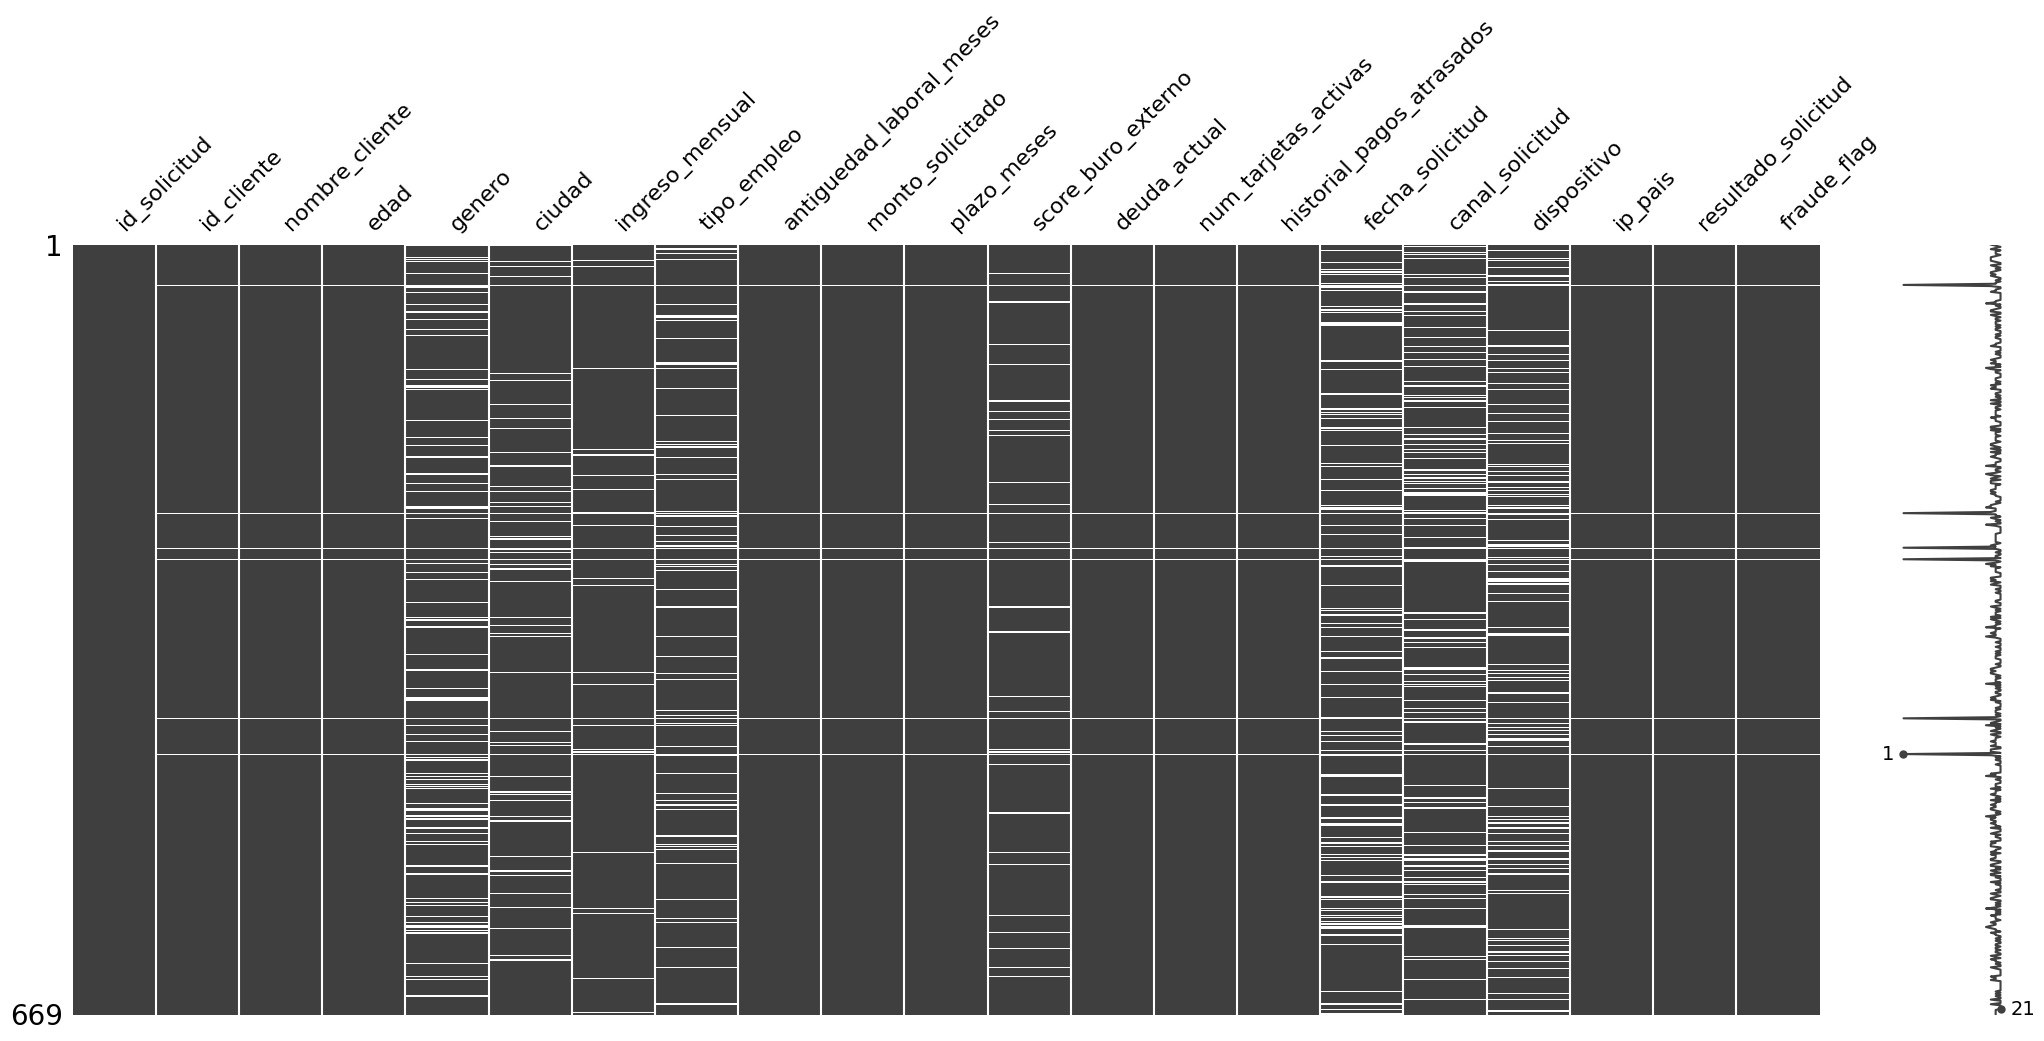

In [8]:
#Patron de valores
msno.matrix(df)
#se demuestra graficamente que las las columnas con mayor cantidad
#de datos faltantes

In [12]:
#generacion de reporte de calidad de datos
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Reporte de calidad — NeoCredit SA", minimal=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:00<00:00, 65.68it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

**Paso 3: Tratamiento de datos faltantes**

In [ ]:
#conteo de valores nulos por columnas
missing_values_count=df.isnull().sum()
missing_values_count

In [ ]:
#Porcentaje de valores nulos por columna
(missing_values_count / len(df) * 100).round(2)

**Estrategia 1: Eliminar filas con valores nulos**

In [ ]:
#Eliminación de filas con al menos un valor nulo

df_sin_filas_nulas = df.dropna()
print(f"Filas originales: {len(df)}")
print(f"Filas después de eliminar nulos: {len(df_sin_filas_nulas)}")
print(f"Filas perdidas: {(1 - len(df_sin_filas_nulas) / len(df)):.1%}")

#al evidenciar que el porcentaje de eliminiacion es mas del 5% de los datos
#no es adecuado eliminiar todas las filas nulas

**Estrategia 2: Eliminar columnas con valores nulos**

In [ ]:
#Eliminación de columnas con al menos un valor nulo

df_sin_columnas_nulas = df.dropna(axis=1)
columnas_originales = df.shape[1]
columnas_restantes = df_sin_columnas_nulas.shape[1]
print(f"Columnas originales: {columnas_originales}")
print(f"Columnas restantes: {columnas_restantes}")
print(f"Columnas eliminadas: {columnas_originales - columnas_restantes}")

#al ser la columna Transaction ID la unica que no tiene valores nulos se esta
#eliminado todo el resto de columna lo cual lo cual no es una buena opcion

**Estrategia 3: Imputar los datos**

In [ ]:
#Valores únicos de la columna Total Spent
df["Total Spent"].unique()

#se evidencia que existen valores cadena como 'ERROR' y 'UNKNOWN' lo cual indica
#que el tipo de dato de la columna es cadena cuando deberia ser numerico

In [ ]:
#Conversion de cadena a numero de la columna Total Spent
df["Total Spent"]=pd.to_numeric(df["Total Spent"], errors="coerce") #errors="coerce" transforma automáticamente en NaN cualquier valor que no sea numero
df["Total Spent"].unique()

In [ ]:
#Imputación con el siguiente valor válido (backward fill)
df["Total Spent"]=df["Total Spent"].bfill()
df["Total Spent"].isnull().sum()

#el metod bfill rellena valores faltantes (NaN) en un DataFrame o Serie tomando el siguiente valor válido disponible

In [ ]:
df["Total Spent"].unique()
#se evidendica que ya no existen valores nulos

In [ ]:
#Imputación reproducible con SimpleImputer (scikit-learn)
imputer = SimpleImputer(strategy="median")
df[["Total Spent"]] = imputer.fit_transform(df[["Total Spent"]])

In [ ]:
df["Total Spent"].unique()

In [ ]:
#Normalización de tipo para todas las columnas numéricas del dataset
columnas_numericas = ["Quantity", "Price Per Unit", "Total Spent"] #lista de columnas numericas

for columna in columnas_numericas:
  df[columna] = pd.to_numeric(df[columna], errors="coerce")

df[columnas_numericas].dtypes # se verica que el tipo de datos sea numerico

In [ ]:
#se valida si hay valores nulos en la columna Price Per Unit
df["Price Per Unit"].unique()

In [ ]:
#se valida si hay valores nulos en la columna Quantity
df["Quantity"].unique()

In [ ]:
# Eliminar filas donde 'Quantity' es nulo
df_cleaned = df.dropna(subset=['Quantity'])

print(f"Filas originales: {len(df)}")
print(f"Filas después de eliminar nulos en 'Quantity': {len(df_cleaned)}")
print(f"Valores nulos en 'Quantity' después de la eliminación: {df_cleaned['Quantity'].isnull().sum()}")


In [ ]:
# Eliminar filas donde 'Price Per Unit' es nulo
df_cleaned = df.dropna(subset=['Price Per Unit'])

print(f"Filas originales: {len(df)}")
print(f"Filas después de eliminar nulos en 'Price Per Unit': {len(df_cleaned)}")
print(f"Valores nulos en 'Price Per Unit' después de la eliminación: {df_cleaned['Price Per Unit'].isnull().sum()}")

In [ ]:
df.head(100)
#se evidencia que al haber aplicado el metodo bfill sobre la columna Total Spent
#se genera una inconsistencia en los casos en que si se tiene el precio unicario
#y la cantidad como en el caso de la fila con indice 2

**Paso 5: Escalado y normalización de datos**

In [ ]:
df_cleaned.info()

**Escalado**

In [ ]:
#MinMaxScaler: reescala los valores al rango [0, 1]
precio_original = df_cleaned[["Price Per Unit"]].copy()

scaler = MinMaxScaler()
df_cleaned["Price Per Unit_scaled"] = scaler.fit_transform(df_cleaned[["Price Per Unit"]])

print("Original -> min:", precio_original.min().values[0], " max:",precio_original.max().values[0])
print("Escalado -> min:", df_cleaned["Price Per Unit_scaled"].min(), " max:", df_cleaned["Price Per Unit_scaled"].max())

In [ ]:
df_cleaned.head(100)

In [ ]:
#RobustScaler: usa la mediana y el rango intercuartílico, robusto a valores atípicos
robust_scaler = RobustScaler()
df_cleaned["Price Per Unit_robust"] = robust_scaler.fit_transform(df_cleaned[["Price Per Unit"]])

In [ ]:
df_cleaned.head(10)

In [ ]:
#MaxAbsScaler: divide entre el valor absoluto máximo; útil en datos dispersos (sparse)
maxabs_scaler = MaxAbsScaler()
df_cleaned["Price Per Unit_maxabs"] = maxabs_scaler.fit_transform(df_cleaned[["Price Per Unit"]])

In [ ]:
df_cleaned.head()

**Normalización**

In [ ]:
#Verificación del tipo numérico antes de normalizar
df_cleaned["Price Per Unit"] = pd.to_numeric(df_cleaned["Price Per Unit"], errors="coerce")

In [ ]:
#Transformación Box-Cox con PowerTransformer
pt = PowerTransformer(method="box-cox") # requiere valores estrictamente positivos
df_cleaned["Price Per Unit_boxcox"] = pt.fit_transform(df_cleaned[["Price Per Unit"]].dropna())

In [ ]:
df_cleaned.info()

In [ ]:
#Estandarización: media 0 y desviación estándar 1
std_scaler = StandardScaler()
df_cleaned["Price Per Unit_standard"] = std_scaler.fit_transform(df_cleaned[["Price Per Unit"]])

In [ ]:
df_cleaned.head()

In [ ]:
df_cleaned = df_cleaned.reset_index(drop=True)
df_cleaned.info()

In [ ]:
#Normalización L2 sobre múltiples columnas (fila a fila)
filas_validas = df_cleaned[["Quantity", "Price Per Unit"]].dropna()

l2_normalizer = Normalizer(norm="l2")
df_cleaned.loc[filas_validas.index, ["Quantity_l2", "Price Per Unit_l2"]] = (
    l2_normalizer.fit_transform(filas_validas)
)

**Paso 6: Validación automatizada de calidad de datos**


In [ ]:
#Definición y ejecución de un esquema de validación con pandera
schema = DataFrameSchema({
        "Transaction ID": Column(str, nullable=False, unique=True),
        "Quantity": Column(float, Check.ge(0), nullable=True),
        "Price Per Unit": Column(float, Check.gt(0), nullable=True),
        "Total Spent": Column(float, Check.ge(0), nullable=True),
})
try:
  schema.validate(df_cleaned, lazy=True)
  print("El dataset cumple con las reglas de calidad definidas.")
except pa.errors.SchemaErrors as err:
  print(err.failure_cases)